In [112]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np
import seaborn as sns

In [77]:
(X_train, y_train) , (X_test, y_test) = keras.datasets.mnist.load_data()

In [78]:
len(X_train)

60000

In [79]:
len(X_test)

10000

In [80]:
X_train = X_train / 255
X_test = X_test / 255

In [81]:
X_train[0].shape

(28, 28)

In [82]:
#X_train[0]

In [83]:
plt.matshow(X_train[0])

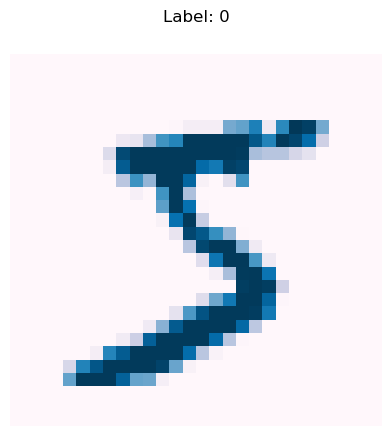

In [84]:
# Show the image at index 5
plt.imshow(X_train[0], cmap='PuBu')

# Optional: Add a title and hide axis numbers for a cleaner look
plt.title(f"Label: {y_train[1]}")
plt.axis('off')

# Display the plot
plt.show()

In [85]:
y_train[2]

np.uint8(4)

In [86]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

In [87]:
X_train_flattened = X_train.reshape(len(X_train),28*28)
X_test_flattened = X_test.reshape(len(X_test),28*28)

In [88]:
model = keras.Sequential([
    keras.layers.Dense(10,input_shape=(784,),activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened,y_train,epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8771 - loss: 0.4713
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9149 - loss: 0.3045
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9208 - loss: 0.2837
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9236 - loss: 0.2735  
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9262 - loss: 0.2672


In [89]:
model.evaluate(X_test_flattened , y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9258 - loss: 0.2678   


[0.26781463623046875, 0.9258000254631042]

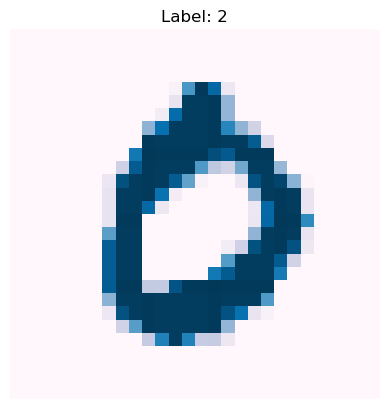

In [101]:
# Show the image at index 5
plt.imshow(X_test[3], cmap='PuBu')

# Optional: Add a title and hide axis numbers for a cleaner look
plt.title(f"Label: {y_test[1]}")
plt.axis('off')

# Display the plot
plt.show()

In [98]:
y_predicted = model.predict(X_test_flattened)
y_predicted[1]

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 687us/step


array([3.8178825e-01, 7.4830595e-03, 9.9959898e-01, 3.0054125e-01,
       4.0511344e-10, 8.3265275e-01, 8.6360776e-01, 1.6840021e-12,
       1.3527487e-01, 2.7555100e-09], dtype=float32)

In [107]:
print(np.argmax(y_predicted[2]))

1


In [109]:
y_predicted_labels = [np.argmax(i) for i in y_predicted]
y_predicted_labels[:5]

[np.int64(7), np.int64(2), np.int64(1), np.int64(0), np.int64(4)]

In [111]:
cm = tf.math.confusion_matrix(labels = y_test, predictions = y_predicted_labels)
cm

<tf.Tensor: shape=(10, 10), dtype=int32, numpy=
array([[ 963,    0,    1,    2,    0,    5,    6,    2,    1,    0],
       [   0, 1112,    3,    2,    0,    1,    4,    2,   11,    0],
       [   6,   10,  938,    8,    5,    3,   11,   10,   36,    5],
       [   4,    0,   26,  904,    0,   30,    2,   16,   21,    7],
       [   1,    1,    9,    1,  899,    0,   10,    4,   11,   46],
       [  11,    3,    5,   21,   10,  779,   17,    8,   30,    8],
       [  13,    3,    8,    1,    7,   11,  911,    2,    2,    0],
       [   1,    6,   25,    2,    6,    0,    0,  954,    2,   32],
       [   7,    8,    9,   15,    9,   21,   10,   13,  874,    8],
       [  10,    7,    2,    8,   21,    7,    0,   24,    6,  924]],
      dtype=int32)>

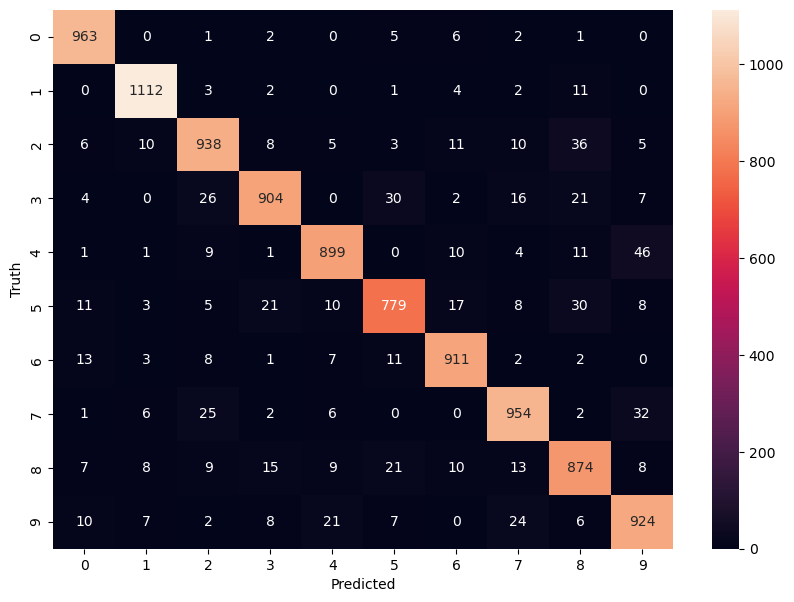

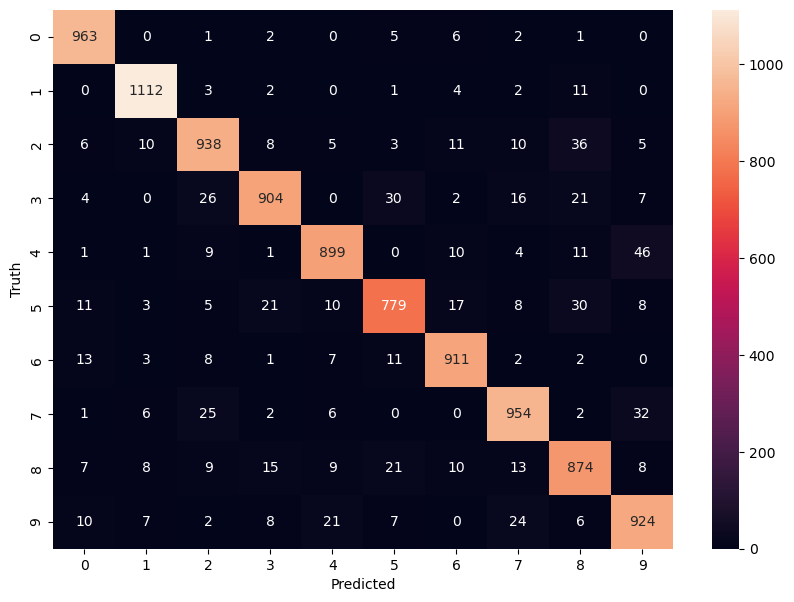

In [117]:
plt.figure(figsize = (10,7))
sns.heatmap(cm,annot = True , fmt = 'd')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [120]:
model = keras.Sequential([
    keras.layers.Dense(100,input_shape=(784,),activation = 'relu'),        # Hidden layer 
    keras.layers.Dense(10,activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train_flattened,y_train,epochs = 5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9228 - loss: 0.2732
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9642 - loss: 0.1222
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9746 - loss: 0.0854
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9803 - loss: 0.0644
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9844 - loss: 0.0507


In [121]:
model.evaluate(X_test_flattened,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0758   


[0.07576938718557358, 0.9750000238418579]

In [124]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(100,input_shape=(784,),activation = 'relu'),        # Hidden layer 
    keras.layers.Dense(10,activation = 'sigmoid')
])

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

model.fit(X_train,y_train,epochs = 5)

D:\AI-ML\software\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
D:\AI-ML\software\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9225 - loss: 0.2739
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9643 - loss: 0.1218
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9741 - loss: 0.0849
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9813 - loss: 0.0636
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9846 - loss: 0.0505
